In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

# 最終Test患者別予測結果
TEST_PRED_CSV = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "05_Evaluation",
    "TaskA_CXR_Test患者別予測結果.csv"
)

# 最終モデル
CHECKPOINT_PATH = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "04_Training",
    "AugB_LR1e-5_seed42_weighted_best.pth"
)

# CXR画像
PNG_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "01_前処理",
    "processed_png_1277"
)

# Grad-CAM出力先
GRADCAM_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "06_GradCAM"
)

os.makedirs(GRADCAM_DIR, exist_ok=True)

print("Test predictions:", os.path.exists(TEST_PRED_CSV))
print("Checkpoint      :", os.path.exists(CHECKPOINT_PATH))
print("PNG directory   :", os.path.isdir(PNG_DIR))
print("GradCAM output  :", GRADCAM_DIR)

Mounted at /content/drive
Test predictions: True
Checkpoint      : True
PNG directory   : True
GradCAM output  : /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM


In [2]:
test_pred_df = pd.read_csv(TEST_PRED_CSV)

print("Columns:", test_pred_df.columns.tolist())
print("n:", len(test_pred_df))
print("Deaths:", int(test_pred_df["true_label"].sum()))

display(test_pred_df.head())

Columns: ['Subject ID', 'true_label', 'prob_death', 'pred_label', 'correct', 'model_name']
n: 128
Deaths: 17


,Subject ID,true_label,prob_death,pred_label,correct,model_name
0,A507869,1,0.629968,1,1,CXR_ResNet18
1,A590353,0,0.150122,0,1,CXR_ResNet18
2,A292777,1,0.337573,0,0,CXR_ResNet18
3,A071731,0,0.396800,0,1,CXR_ResNet18
4,A843575,0,0.239269,0,1,CXR_ResNet18


In [3]:
print("\n=== Classification groups ===")

group_counts = (
    test_pred_df
    .groupby(["true_label", "pred_label"])
    .size()
)

print(group_counts)


=== Classification groups ===
true_label  pred_label
0           0             104
            1               7
1           0               5
            1              12
dtype: int64


In [4]:
# ============================================
# Select 4 cases from each TP / TN / FP / FN
# based ONLY on saved predicted probability
# ============================================

# TN：生存、正解
# 「明らかに正解」＝死亡確率が最も低い4例
tn = (
    test_pred_df[
        (test_pred_df["true_label"] == 0) &
        (test_pred_df["pred_label"] == 0)
    ]
    .sort_values(
        ["prob_death", "Subject ID"],
        ascending=[True, True]
    )
    .head(4)
    .copy()
)

# FP：生存だが死亡と誤予測
# 「明らかに間違い」＝死亡確率が最も高い4例
fp = (
    test_pred_df[
        (test_pred_df["true_label"] == 0) &
        (test_pred_df["pred_label"] == 1)
    ]
    .sort_values(
        ["prob_death", "Subject ID"],
        ascending=[False, True]
    )
    .head(4)
    .copy()
)

# TP：死亡、正解
# 「明らかに正解」＝死亡確率が最も高い4例
tp = (
    test_pred_df[
        (test_pred_df["true_label"] == 1) &
        (test_pred_df["pred_label"] == 1)
    ]
    .sort_values(
        ["prob_death", "Subject ID"],
        ascending=[False, True]
    )
    .head(4)
    .copy()
)

# FN：死亡だが生存と誤予測
# 「明らかに間違い」＝死亡確率が最も低い4例
fn = (
    test_pred_df[
        (test_pred_df["true_label"] == 1) &
        (test_pred_df["pred_label"] == 0)
    ]
    .sort_values(
        ["prob_death", "Subject ID"],
        ascending=[True, True]
    )
    .head(4)
    .copy()
)

tn["group"] = "TN_survivor_correct"
fp["group"] = "FP_survivor_wrong"
tp["group"] = "TP_deceased_correct"
fn["group"] = "FN_deceased_wrong"

gradcam_cases = pd.concat(
    [tp, tn, fp, fn],
    ignore_index=True
)

display(
    gradcam_cases[
        [
            "Subject ID",
            "true_label",
            "prob_death",
            "pred_label",
            "group"
        ]
    ]
)

print("Selected:", len(gradcam_cases))

,Subject ID,true_label,prob_death,pred_label,group
0,A164683,1,0.975495,1,TP_deceased_correct
1,A387558,1,0.962105,1,TP_deceased_correct
2,A701587,1,0.958302,1,TP_deceased_correct
3,A487800,1,0.918126,1,TP_deceased_correct
4,A209538,0,0.017999,0,TN_survivor_correct
5,A759584,0,0.024324,0,TN_survivor_correct
6,A911613,0,0.025486,0,TN_survivor_correct
7,A769617,0,0.025648,0,TN_survivor_correct
8,A878506,0,0.934876,1,FP_survivor_wrong
9,A293330,0,0.932838,1,FP_survivor_wrong


Selected: 16


In [5]:
selection_path = os.path.join(
    GRADCAM_DIR,
    "TaskA_CXR_GradCAM_16症例選定一覧.csv"
)

gradcam_cases.to_csv(
    selection_path,
    index=False
)

print("Saved:", selection_path)

Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM/TaskA_CXR_GradCAM_16症例選定一覧.csv


In [6]:
# ============================================
# Cell 4: Load final CXR model
# ============================================

import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 1)
model = model.to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Device:", device)
print("Checkpoint loaded.")

for key in [
    "condition_name",
    "epoch",
    "val_roc_auc",
    "val_pr_auc",
    "val_loss",
    "seed",
    "lr",
    "pos_weight"
]:
    if key in checkpoint:
        print(f"{key}: {checkpoint[key]}")

Device: cuda
Checkpoint loaded.
condition_name: AugB_LR1e-5_seed42_weighted
epoch: 12
val_roc_auc: 0.848966613672496
val_pr_auc: 0.5606217053146204
val_loss: 0.857040524482727
seed: 42
lr: 1e-05
pos_weight: 6.562962962962963


In [7]:
# ============================================
# Cell 5: Set Grad-CAM target layer
# ============================================

target_layer = model.layer4[-1].conv2

print(target_layer)


Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [8]:
# ============================================
# Cell 6: Grad-CAM class
# ============================================

import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # forward時の特徴マップを保存
        self.forward_hook = target_layer.register_forward_hook(
            self._save_activation
        )

        # backward時の勾配を保存
        self.backward_hook = target_layer.register_full_backward_hook(
            self._save_gradient
        )

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()

        # raw logit
        output = self.model(input_tensor)
        score = output[0, 0]

        # mortality方向の勾配
        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        # channelごとの重み
        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(
            activations.shape[1:],
            device=activations.device
        )

        for i, w in enumerate(weights):
            cam += w * activations[i]

        # 正の寄与のみ
        cam = F.relu(cam)

        # 0〜1に正規化
        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        probability = torch.sigmoid(output)[0, 0].item()

        return cam.cpu().numpy(), probability

In [9]:
# ============================================
# Cell 7: Load one case for Grad-CAM test
# ============================================

patient_id = gradcam_cases.iloc[0]["Subject ID"]

img_path = os.path.join(
    PNG_DIR,
    f"{patient_id}.png"
)

print("Patient ID:", patient_id)
print("Image exists:", os.path.exists(img_path))
print("Image path:", img_path)

# 元画像読み込み
img = Image.open(img_path).convert("L")

# モデル入力用
img_rgb = Image.merge("RGB", (img, img, img))

input_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = input_transform(img_rgb).unsqueeze(0).to(device)

print("Input shape:", input_tensor.shape)

Patient ID: A164683
Image exists: True
Image path: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/01_前処理/processed_png_1277/A164683.png
Input shape: torch.Size([1, 3, 224, 224])


In [10]:
# ============================================
# Cell 8: Generate Grad-CAM for one case
# ============================================

gradcam = GradCAM(
    model=model,
    target_layer=target_layer
)

cam, prob = gradcam.generate(input_tensor)

print("Patient ID:", patient_id)
print("Recomputed mortality probability:", prob)
print("CAM shape:", cam.shape)
print("CAM min:", cam.min())
print("CAM max:", cam.max())

Patient ID: A164683
Recomputed mortality probability: 0.9754952192306519
CAM shape: (7, 7)
CAM min: 0.0
CAM max: 1.0


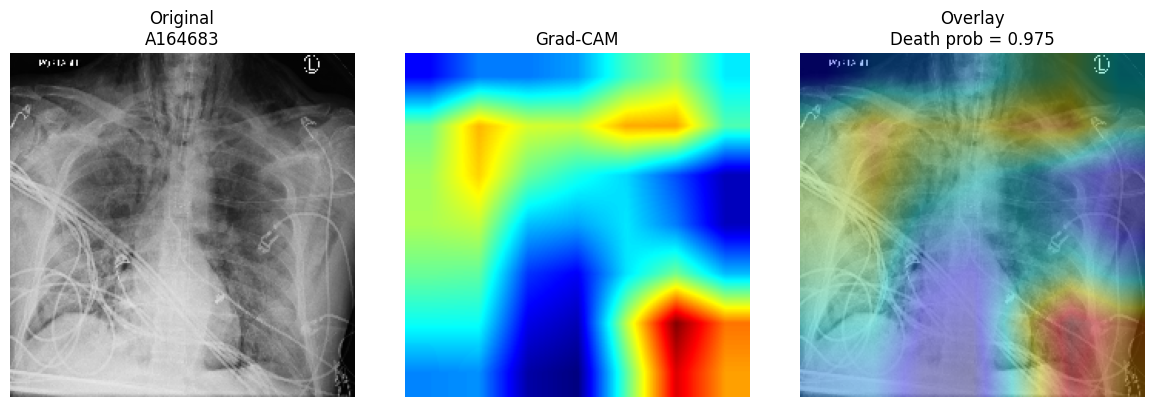

In [11]:
# ============================================
# Cell 9: Visualize one Grad-CAM
# ============================================

import cv2
import matplotlib.pyplot as plt

# 元画像を224x224で表示用に準備
display_img = Image.open(img_path).convert("L").resize((224, 224))
display_img = np.array(display_img).astype(np.float32)

# 0-255へ正規化
display_img -= display_img.min()
if display_img.max() > 0:
    display_img /= display_img.max()

display_img = (display_img * 255).astype(np.uint8)

# CAMを224x224へ拡大
cam_resized = cv2.resize(
    cam,
    (224, 224),
    interpolation=cv2.INTER_LINEAR
)

# ヒートマップ化
heatmap = np.uint8(255 * cam_resized)
heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)
heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

# 元画像をRGB化
display_rgb = np.stack(
    [display_img, display_img, display_img],
    axis=-1
)

# Overlay
overlay = cv2.addWeighted(
    display_rgb,
    0.65,
    heatmap,
    0.35,
    0
)

# 表示
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(display_img, cmap="gray")
plt.title(f"Original\n{patient_id}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay\nDeath prob = {prob:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# Cell 10: Sanity check with one TN case
# ============================================

tn_row = gradcam_cases[
    gradcam_cases["group"] == "TN_survivor_correct"
].iloc[0]

tn_patient_id = tn_row["Subject ID"]

tn_img_path = os.path.join(
    PNG_DIR,
    f"{tn_patient_id}.png"
)

tn_img = Image.open(tn_img_path).convert("L")
tn_img_rgb = Image.merge("RGB", (tn_img, tn_img, tn_img))

tn_input_tensor = (
    input_transform(tn_img_rgb)
    .unsqueeze(0)
    .to(device)
)

tn_cam, tn_prob = gradcam.generate(tn_input_tensor)

print("Patient ID:", tn_patient_id)
print("Saved probability:", tn_row["prob_death"])
print("Recomputed probability:", tn_prob)
print("CAM shape:", tn_cam.shape)
print("CAM min:", tn_cam.min())
print("CAM max:", tn_cam.max())

Patient ID: A209538
Saved probability: 0.017999252
Recomputed probability: 0.017999377101659775
CAM shape: (7, 7)
CAM min: 0.0
CAM max: 1.0


In [13]:
# ============================================
# Cell 11: Generate and save Grad-CAM for all 16 cases
# ============================================

save_records = []

for _, row in gradcam_cases.iterrows():

    patient_id = row["Subject ID"]
    true_label = int(row["true_label"])
    pred_label = int(row["pred_label"])
    saved_prob = float(row["prob_death"])
    group = row["group"]

    img_path = os.path.join(
        PNG_DIR,
        f"{patient_id}.png"
    )

    if not os.path.exists(img_path):
        print("Image not found:", patient_id)
        continue

    # -------------------------
    # Load image
    # -------------------------
    img = Image.open(img_path).convert("L")

    img_rgb = Image.merge(
        "RGB",
        (img, img, img)
    )

    input_tensor = (
        input_transform(img_rgb)
        .unsqueeze(0)
        .to(device)
    )

    # -------------------------
    # Grad-CAM
    # -------------------------
    cam, recomputed_prob = gradcam.generate(input_tensor)

    # -------------------------
    # Display image
    # -------------------------
    display_img = img.resize((224, 224))
    display_img = np.array(display_img).astype(np.float32)

    display_img -= display_img.min()

    if display_img.max() > 0:
        display_img /= display_img.max()

    display_img = (
        display_img * 255
    ).astype(np.uint8)

    # Resize CAM
    cam_resized = cv2.resize(
        cam,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    heatmap = np.uint8(
        255 * cam_resized
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    display_rgb = np.stack(
        [display_img, display_img, display_img],
        axis=-1
    )

    overlay = cv2.addWeighted(
        display_rgb,
        0.65,
        heatmap,
        0.35,
        0
    )

    # -------------------------
    # Save figure
    # -------------------------
    fig = plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(display_img, cmap="gray")
    plt.title(
        f"Original\n{patient_id}"
    )
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"{group}\n"
        f"True={true_label}, Pred={pred_label}\n"
        f"Death prob={saved_prob:.3f}"
    )
    plt.axis("off")

    plt.tight_layout()

    out_path = os.path.join(
        GRADCAM_DIR,
        f"{group}_{patient_id}_GradCAM.png"
    )

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    # -------------------------
    # Log
    # -------------------------
    save_records.append({
        "Subject ID": patient_id,
        "group": group,
        "true_label": true_label,
        "pred_label": pred_label,
        "prob_death_saved": saved_prob,
        "prob_death_recomputed": recomputed_prob,
        "probability_difference": abs(
            saved_prob - recomputed_prob
        ),
        "gradcam_path": out_path
    })


print("Saved Grad-CAM images:", len(save_records))

Saved Grad-CAM images: 16


In [14]:
# ============================================
# Cell 12: Save Grad-CAM log
# ============================================

gradcam_log_df = pd.DataFrame(save_records)

log_path = os.path.join(
    GRADCAM_DIR,
    "TaskA_CXR_GradCAM_16症例保存ログ.csv"
)

gradcam_log_df.to_csv(
    log_path,
    index=False
)

print("Saved:", log_path)
print("n =", len(gradcam_log_df))

display(gradcam_log_df.head())

Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM/TaskA_CXR_GradCAM_16症例保存ログ.csv
n = 16


,Subject ID,group,true_label,pred_label,prob_death_saved,prob_death_recomputed,probability_difference,gradcam_path
0,A164683,TP_deceased_correct,1,1,0.975495,0.975495,2.192307e-07,/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR...
1,A387558,TP_deceased_correct,1,1,0.962105,0.962105,1.642181e-07,/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR...
2,A701587,TP_deceased_correct,1,1,0.958302,0.958302,2.230034e-07,/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR...
3,A487800,TP_deceased_correct,1,1,0.918126,0.918126,2.917610e-07,/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR...
4,A209538,TN_survivor_correct,0,0,0.017999,0.017999,1.251017e-07,/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR...


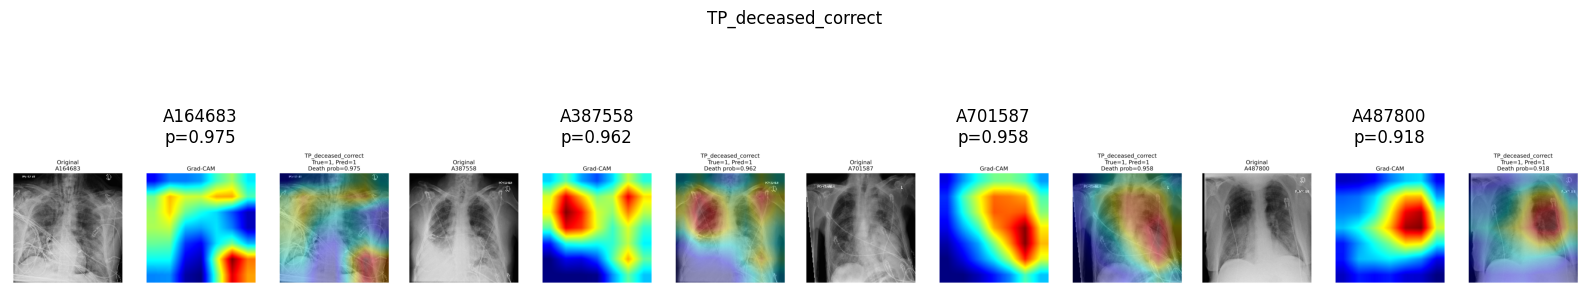

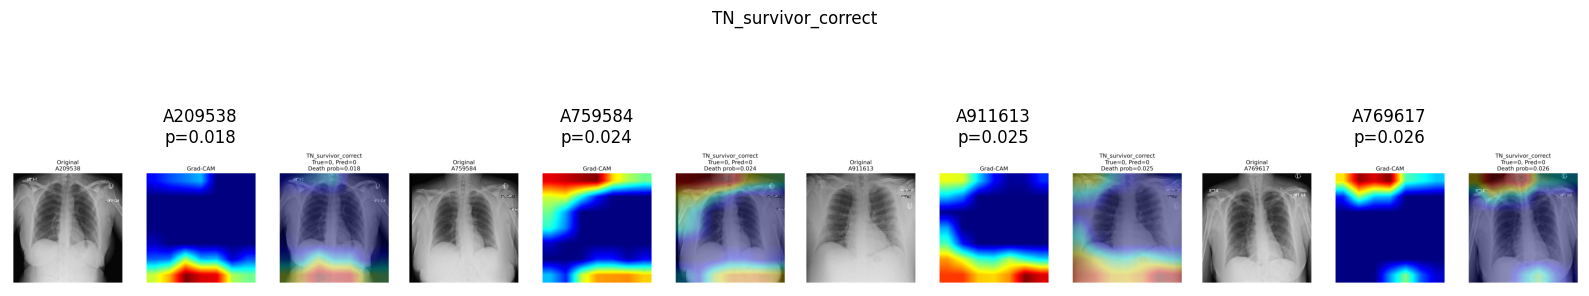

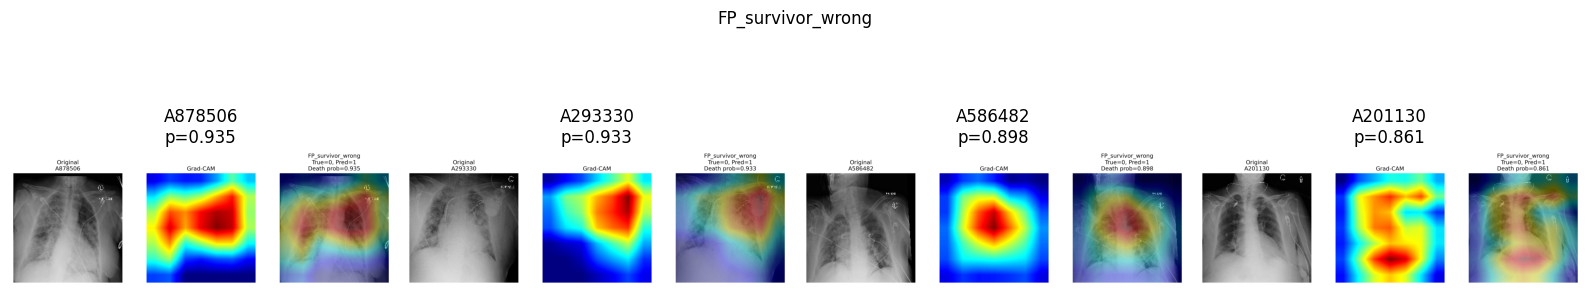

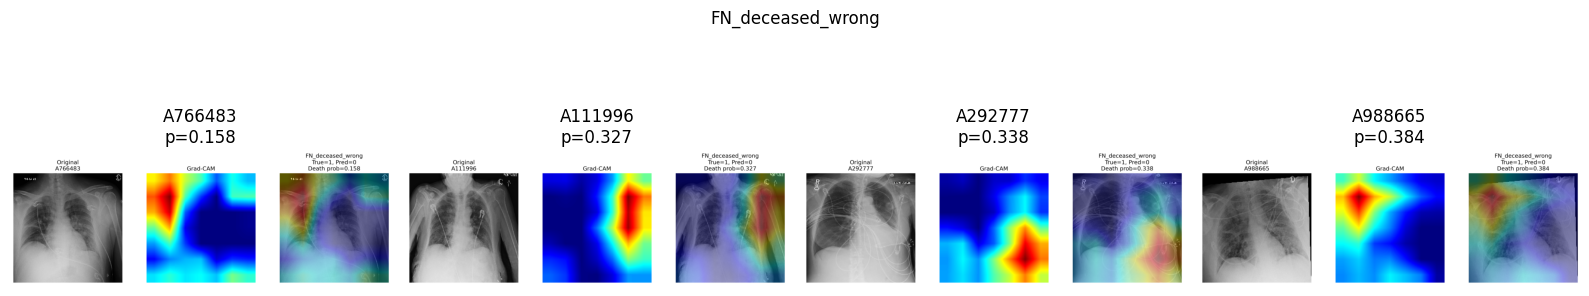

In [15]:
# ============================================
# Cell 13: Display 4 cases in each group
# ============================================

group_order = [
    "TP_deceased_correct",
    "TN_survivor_correct",
    "FP_survivor_wrong",
    "FN_deceased_wrong"
]

for group_name in group_order:

    subset = gradcam_log_df[
        gradcam_log_df["group"] == group_name
    ]

    fig, axes = plt.subplots(
        1,
        len(subset),
        figsize=(16, 4)
    )

    for ax, (_, row) in zip(axes, subset.iterrows()):

        img = Image.open(
            row["gradcam_path"]
        )

        ax.imshow(img)
        ax.set_title(
            f'{row["Subject ID"]}\n'
            f'p={row["prob_death_saved"]:.3f}'
        )
        ax.axis("off")

    plt.suptitle(group_name)
    plt.tight_layout()
    plt.show()

In [16]:
# ============================================
# Cell 13 revised: Display each group vertically
# ============================================

group_order = [
    "TP_deceased_correct",
    "TN_survivor_correct",
    "FP_survivor_wrong",
    "FN_deceased_wrong"
]

for group_name in group_order:

    subset = gradcam_log_df[
        gradcam_log_df["group"] == group_name
    ].reset_index(drop=True)

    n = len(subset)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(8, 4 * n)
    )

    # n=1対策
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["gradcam_path"])
        ax.imshow(img)
        ax.set_title(
            f'{row["group"]} | {row["Subject ID"]} | '
            f'true={row["true_label"]}, pred={row["pred_label"]}, '
            f'p={row["prob_death_saved"]:.3f}',
            fontsize=11
        )
        ax.axis("off")

    plt.suptitle(group_name, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [17]:
# ============================================
# Cell 14: Save qualitative Grad-CAM review
# ============================================

qualitative_review = pd.DataFrame([
    {
        "group": "TP_deceased_correct",
        "finding": (
            "Activation was observed mainly within the lung fields and overlapped with "
            "some areas of pulmonary infiltration. However, not all visible infiltrative "
            "opacities were highlighted."
        ),
        "interpretation": (
            "The model may have used part of the pulmonary abnormalities as cues for "
            "in-hospital mortality prediction."
        ),
        "caution": (
            "Grad-CAM is a coarse localization method and does not represent complete "
            "lesion segmentation."
        )
    },
    {
        "group": "TN_survivor_correct",
        "finding": (
            "Clear mortality-class activation within the lung fields was limited, and "
            "relative activation was observed mainly outside the lung fields."
        ),
        "interpretation": (
            "There was little clear pulmonary activation supporting the mortality score."
        ),
        "caution": (
            "Because the target was the mortality logit and each heatmap was normalized "
            "individually, this should not be interpreted as the model using extrapulmonary "
            "regions to predict survival."
        )
    },
    {
        "group": "FP_survivor_wrong",
        "finding": (
            "Activation was concentrated mainly within the lung fields, where extensive "
            "infiltrative opacities were visually present."
        ),
        "interpretation": (
            "The model may have captured severe-appearing pulmonary abnormalities but "
            "overestimated their association with final in-hospital mortality."
        ),
        "caution": (
            "CXR severity and final mortality are not equivalent, and prognosis also "
            "depends on clinical factors not available to the image-only model."
        )
    },
    {
        "group": "FN_deceased_wrong",
        "finding": (
            "Pulmonary activation was often limited, while activation was observed in "
            "extrapulmonary regions such as bones, image margins, or medical devices."
        ),
        "interpretation": (
            "The model may have failed to capture mortality-related pulmonary features "
            "adequately and may have relied on non-pathological image features in some cases."
        ),
        "caution": (
            "This pattern may suggest shortcut learning, but it cannot be established "
            "from four cases alone."
        )
    }
])

review_path = os.path.join(
    GRADCAM_DIR,
    "TaskA_CXR_GradCAM_定性的所見まとめ.csv"
)

qualitative_review.to_csv(
    review_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", review_path)

display(qualitative_review)

Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM/TaskA_CXR_GradCAM_定性的所見まとめ.csv


,group,finding,interpretation,caution
0,TP_deceased_correct,Activation was observed mainly within the lung...,The model may have used part of the pulmonary ...,Grad-CAM is a coarse localization method and d...
1,TN_survivor_correct,Clear mortality-class activation within the lu...,There was little clear pulmonary activation su...,Because the target was the mortality logit and...
2,FP_survivor_wrong,Activation was concentrated mainly within the ...,The model may have captured severe-appearing p...,CXR severity and final mortality are not equiv...
3,FN_deceased_wrong,"Pulmonary activation was often limited, while ...",The model may have failed to capture mortality...,"This pattern may suggest shortcut learning, bu..."


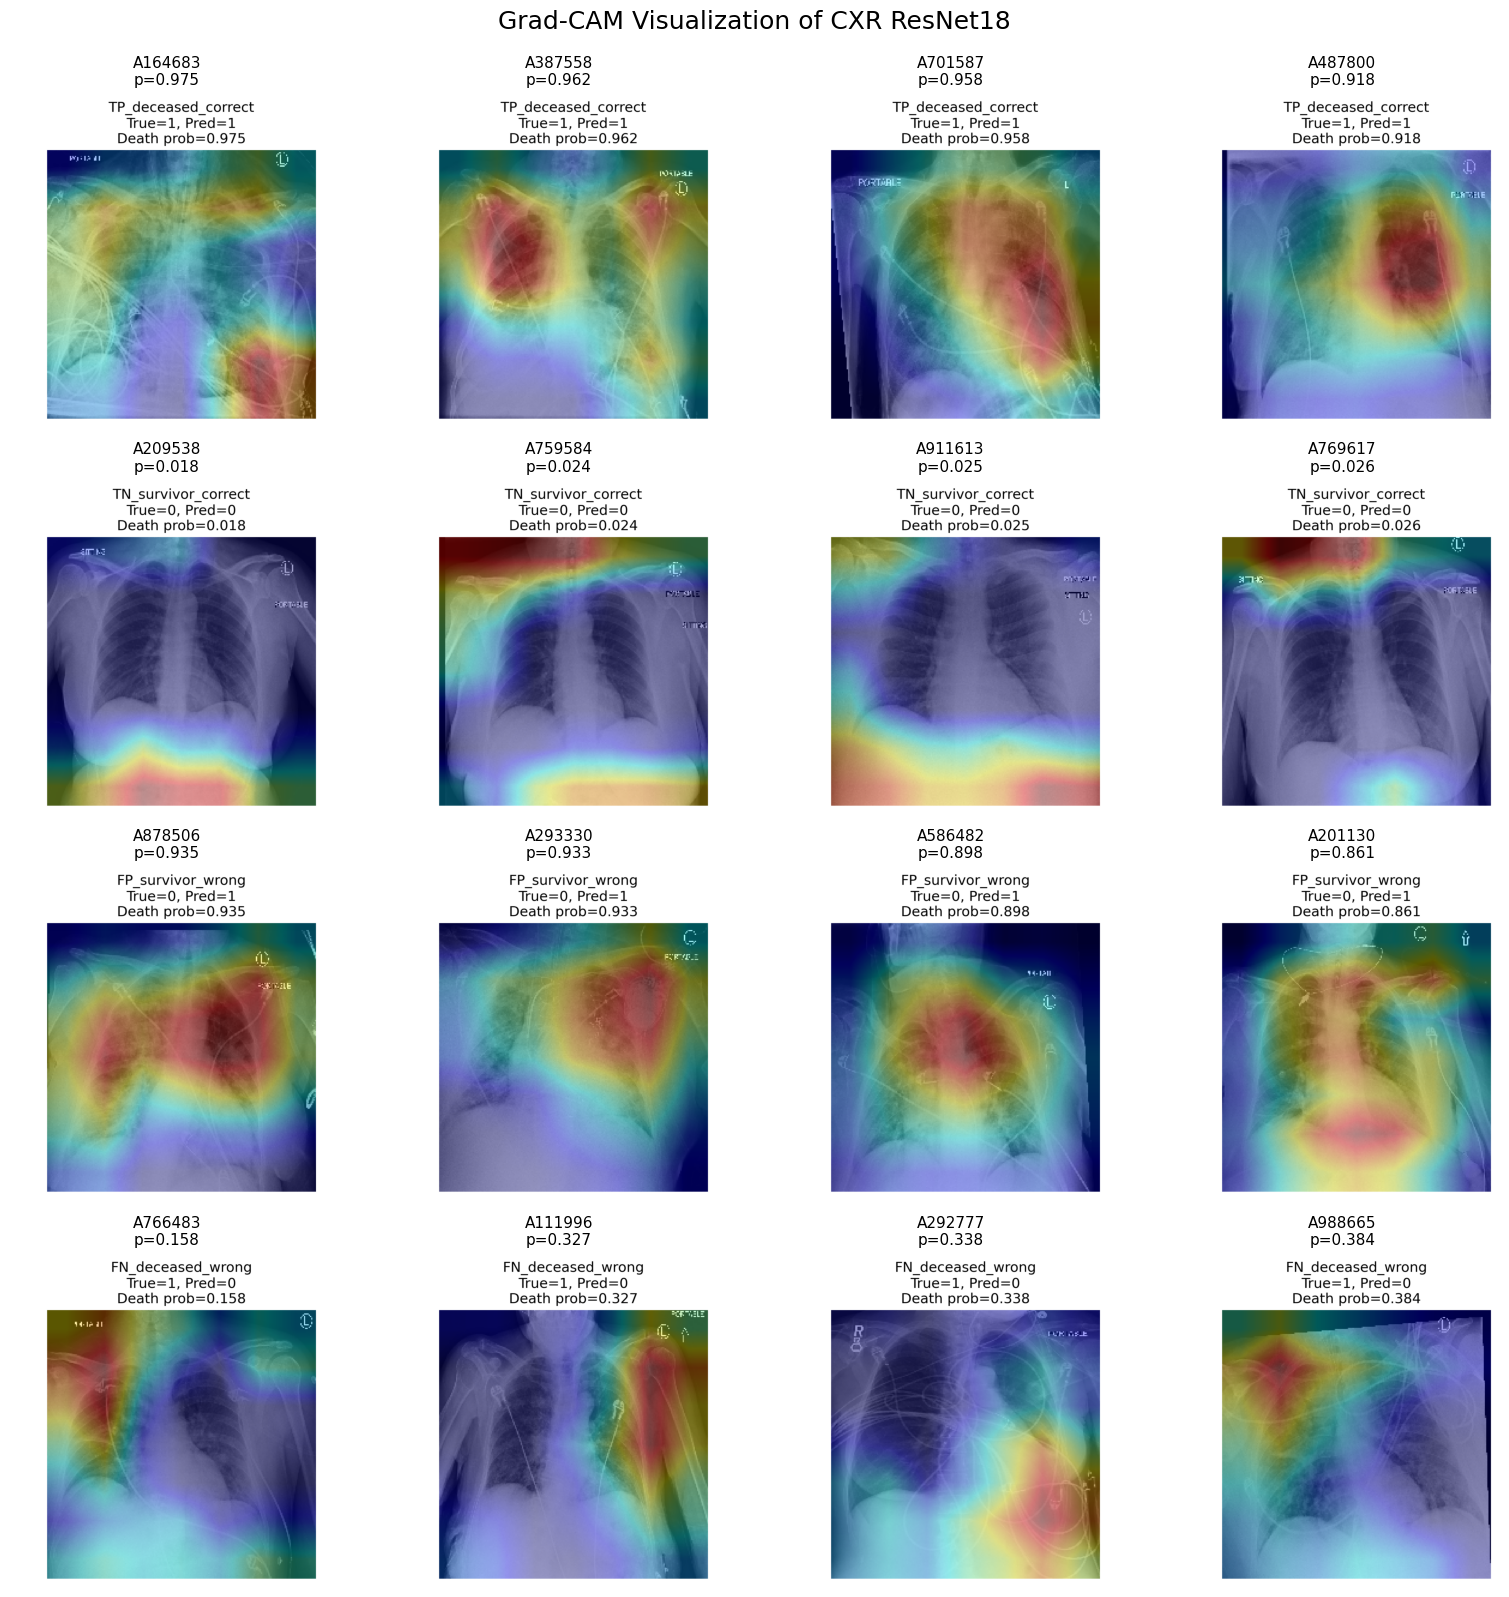

Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM/TaskA_CXR_GradCAM_4x4_final_panel.png


In [18]:
# ============================================
# Cell 15: Final 4x4 Grad-CAM panel
# ============================================

import matplotlib.pyplot as plt
from PIL import Image

group_order = [
    "TP_deceased_correct",
    "TN_survivor_correct",
    "FP_survivor_wrong",
    "FN_deceased_wrong"
]

group_titles = {
    "TP_deceased_correct": "TP: Deceased / Correct",
    "TN_survivor_correct": "TN: Survivor / Correct",
    "FP_survivor_wrong": "FP: Survivor / Misclassified",
    "FN_deceased_wrong": "FN: Deceased / Misclassified"
}

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 16)
)

for row_idx, group_name in enumerate(group_order):

    subset = (
        gradcam_log_df[
            gradcam_log_df["group"] == group_name
        ]
        .reset_index(drop=True)
    )

    for col_idx in range(4):

        ax = axes[row_idx, col_idx]

        row = subset.iloc[col_idx]

        # 既に保存した3-panel画像を読み込み
        full_img = Image.open(row["gradcam_path"])

        # 右1/3のOverlay部分だけ切り出す
        w, h = full_img.size

        overlay_crop = full_img.crop(
            (
                int(w * 2 / 3),
                0,
                w,
                h
            )
        )

        ax.imshow(overlay_crop)

        ax.set_title(
            f'{row["Subject ID"]}\n'
            f'p={row["prob_death_saved"]:.3f}',
            fontsize=11
        )

        ax.axis("off")

        # 各行の左端にGroup名
        if col_idx == 0:
            ax.set_ylabel(
                group_titles[group_name],
                fontsize=13,
                rotation=90,
                labelpad=15
            )

plt.suptitle(
    "Grad-CAM Visualization of CXR ResNet18",
    fontsize=18,
    y=0.995
)

plt.tight_layout()

panel_path = os.path.join(
    GRADCAM_DIR,
    "TaskA_CXR_GradCAM_4x4_final_panel.png"
)

plt.savefig(
    panel_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", panel_path)

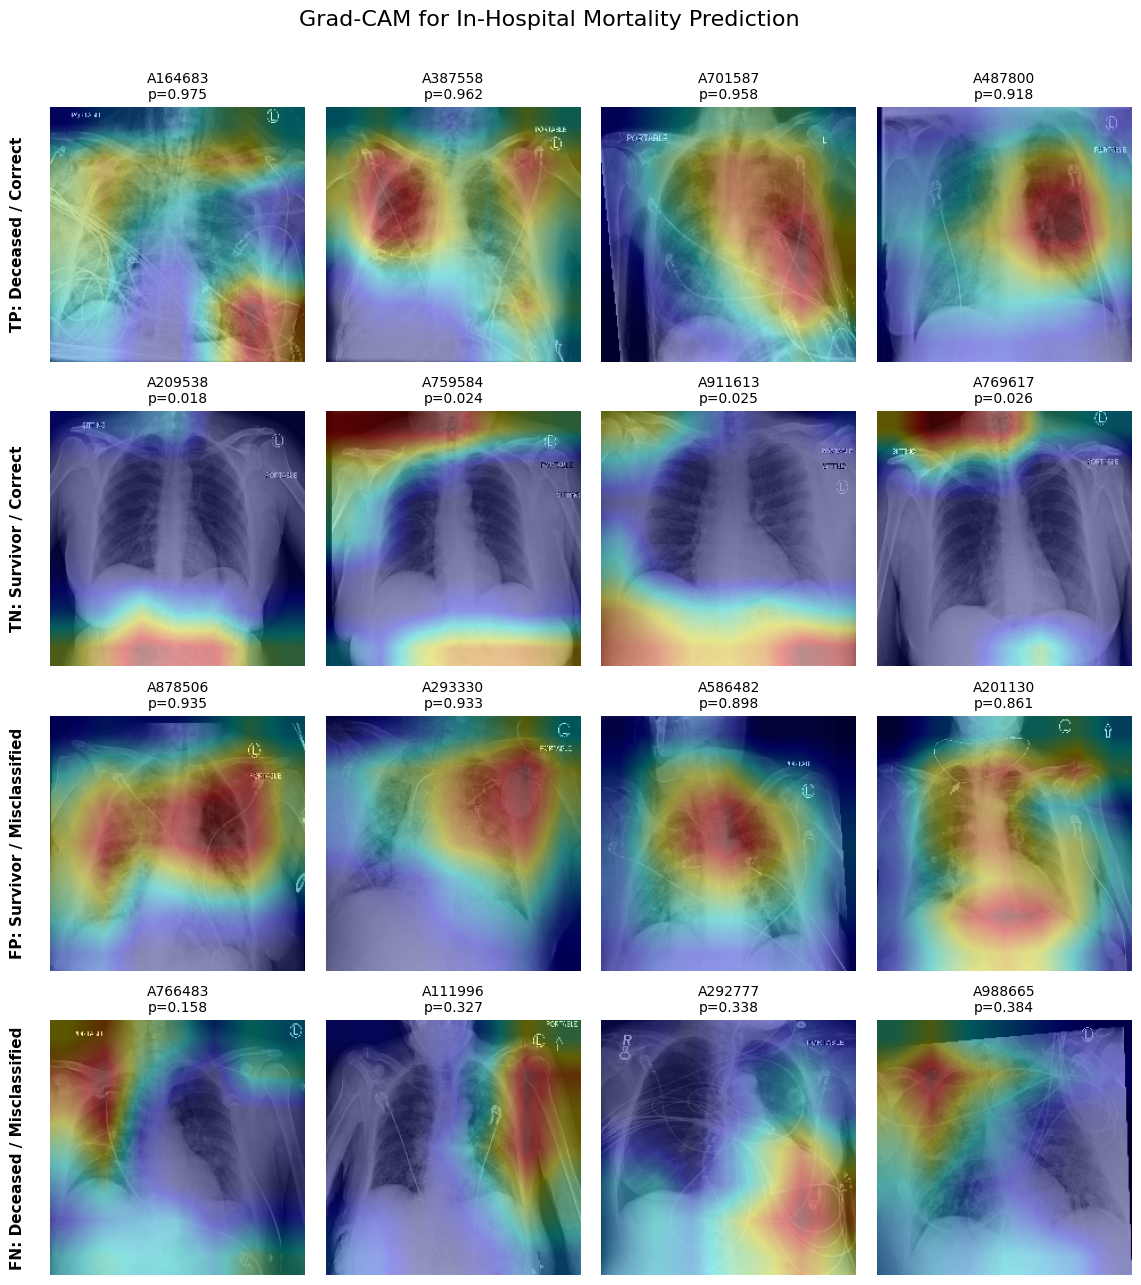

Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM/TaskA_CXR_GradCAM_4x4_final_panel_v2.png


In [19]:
# ============================================
# Cell 15 revised:
# Clean 4x4 Grad-CAM panel for paper/presentation
# ============================================

group_order = [
    "TP_deceased_correct",
    "TN_survivor_correct",
    "FP_survivor_wrong",
    "FN_deceased_wrong"
]

group_titles = {
    "TP_deceased_correct": "TP: Deceased / Correct",
    "TN_survivor_correct": "TN: Survivor / Correct",
    "FP_survivor_wrong": "FP: Survivor / Misclassified",
    "FN_deceased_wrong": "FN: Deceased / Misclassified"
}

fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 13)
)

for row_idx, group_name in enumerate(group_order):

    subset = (
        gradcam_cases[
            gradcam_cases["group"] == group_name
        ]
        .reset_index(drop=True)
    )

    for col_idx in range(4):

        row = subset.iloc[col_idx]

        patient_id = row["Subject ID"]
        prob = float(row["prob_death"])

        img_path = os.path.join(
            PNG_DIR,
            f"{patient_id}.png"
        )

        # ----- model input -----
        img = Image.open(img_path).convert("L")
        img_rgb = Image.merge("RGB", (img, img, img))

        input_tensor = (
            input_transform(img_rgb)
            .unsqueeze(0)
            .to(device)
        )

        # ----- Grad-CAM -----
        cam, recomputed_prob = gradcam.generate(input_tensor)

        # ----- image for display -----
        display_img = np.array(
            img.resize((224, 224))
        ).astype(np.float32)

        display_img -= display_img.min()

        if display_img.max() > 0:
            display_img /= display_img.max()

        display_img = (
            display_img * 255
        ).astype(np.uint8)

        display_rgb = np.stack(
            [display_img] * 3,
            axis=-1
        )

        # CAM → 224×224
        cam_resized = cv2.resize(
            cam,
            (224, 224),
            interpolation=cv2.INTER_LINEAR
        )

        heatmap = np.uint8(
            255 * cam_resized
        )

        heatmap = cv2.applyColorMap(
            heatmap,
            cv2.COLORMAP_JET
        )

        heatmap = cv2.cvtColor(
            heatmap,
            cv2.COLOR_BGR2RGB
        )

        overlay = cv2.addWeighted(
            display_rgb,
            0.65,
            heatmap,
            0.35,
            0
        )

        # ----- plot -----
        ax = axes[row_idx, col_idx]

        ax.imshow(overlay)

        ax.set_title(
            f"{patient_id}\np={prob:.3f}",
            fontsize=10
        )

        ax.axis("off")

        # Group label only once per row
        if col_idx == 0:
            ax.text(
                -0.10,
                0.5,
                group_titles[group_name],
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
                fontsize=11,
                fontweight="bold"
            )

plt.suptitle(
    "Grad-CAM for In-Hospital Mortality Prediction",
    fontsize=16,
    y=0.995
)

plt.tight_layout(
    rect=[0.04, 0, 1, 0.98]
)

panel_path_v2 = os.path.join(
    GRADCAM_DIR,
    "TaskA_CXR_GradCAM_4x4_final_panel_v2.png"
)

plt.savefig(
    panel_path_v2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", panel_path_v2)

In [20]:
# ============================================
# Cell 16: Save Grad-CAM manuscript text
# ============================================

gradcam_text = """
[Figure legend]

Figure X. Grad-CAM visualization of the CXR ResNet18 model for in-hospital mortality prediction.
Four cases were selected from each of the true-positive (TP), true-negative (TN), false-positive (FP),
and false-negative (FN) groups using only the saved test-set predicted probabilities before visual
inspection of the images or heatmaps. TP and FP cases with the highest predicted mortality
probabilities and TN and FN cases with the lowest predicted mortality probabilities were selected.
Grad-CAM was generated using the raw mortality logit as the target and layer4.1.conv2, the final
convolutional layer of ResNet18. Each heatmap was normalized independently within each case;
therefore, color intensity should be interpreted as relative spatial activation within a case and not
compared quantitatively between cases.


[Results]

Grad-CAM analysis showed different activation patterns across prediction groups. In TP cases,
activation was predominantly located within the lung fields and overlapped with portions of visible
infiltrative opacities, although not all radiographic abnormalities were highlighted. In TN cases,
clear mortality-class activation within the lung fields was limited, with relative activation frequently
located outside the lungs. FP cases showed prominent activation within the lung fields, often
corresponding to extensive infiltrative opacities that appeared radiographically severe. In FN cases,
pulmonary activation was often limited, whereas activation was observed in extrapulmonary regions,
including bony structures, image margins, and medical devices.


[Discussion]

The Grad-CAM findings suggest that the CXR model used pulmonary abnormalities as prognostic
cues in at least some correctly predicted deceased patients. However, activation overlapped with only
part of the visible infiltrative abnormalities, consistent with the coarse spatial resolution of Grad-CAM
rather than precise lesion segmentation.

False-positive cases were particularly informative because activation was concentrated within
radiographically abnormal lung fields, often in patients with extensive infiltrative opacities. These
cases may represent situations in which the image model appropriately detected severe pulmonary
abnormalities but overestimated their relationship with final in-hospital mortality. This highlights an
inherent limitation of CXR-only mortality prediction, as radiographic severity does not fully determine
clinical outcome.

In contrast, several false-negative cases showed limited pulmonary activation and relatively prominent
activation in extrapulmonary regions such as bony structures, image margins, or medical devices.
This pattern raises the possibility that the model failed to capture mortality-related pulmonary features
adequately and may have relied on non-pathological image characteristics in some cases. Such findings
may be consistent with shortcut learning; however, this interpretation remains exploratory and cannot
be established from a small number of selected cases.

For TN cases, activation outside the lung fields should not be interpreted as evidence that the model
used extrapulmonary regions to predict survival. Because Grad-CAM was generated for the mortality
logit and each heatmap was independently normalized, even weak positive activation can appear
visually prominent in patients with very low predicted mortality probabilities.
"""

text_path = os.path.join(
    GRADCAM_DIR,
    "TaskA_CXR_GradCAM_論文記載案.txt"
)

with open(text_path, "w", encoding="utf-8") as f:
    f.write(gradcam_text)

print("Saved:", text_path)

Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/06_GradCAM/TaskA_CXR_GradCAM_論文記載案.txt
